# Project 5: Customer segmentation with clustering

### Table of contents
- [Project intro: Customer Segmentation with clustering](#project-5-customer-segmentation-with-clustering)
- [Submission Criteria](#submission-criteria)
- [1. Setup: Importing libraries and loading data](#step-1-setup---importing-libraries-and-loading-data)
- [2. EDA](#step-2-exploratory-data-analysis-eda)
  - [2.1 Univariate Analysis](#21-univariate-analysis)
- [3. Submission criteria 1 - Gender & Spending Score](#step-3-submission-criteria-1---gender--spending-score)
- [4. Submission criteria 2 - Feature Engineering and clustering](#step-4-submission-criteria-2-feature-engineering-for-clustering)
  - [4.1 Creating a new feature](#41-creating-a-new-feature)
  - [4.2 Finding the k using elbow method](#42-finding-the-k-using-elbow-method)
  - [4.3 Visualising and Interpreting the segments](#43-visualising-and-interpreting-the-segments)
  - [4.4 Using hierarchical clustering](#44-using-hierarchical-clustering)
- [5. Conclusion](#step-5-conclusion)

## Submission Criteria

Based on the project objectives and the insights gained from the initial analysis, here are the key criteria for your submission:

1.  **Explore Gender vs. Spending Score:** Analyze the relationship between 'Gender' and 'Spending Score (1-100)' to see if gender plays a significant role in spending habits. Visualizations and summary statistics would be helpful here.
2.  **Apply Feature Engineering for Clustering:** Create a new feature using existing data (Feature Engineering). Then, explore if clustering can be effectively performed using this newly engineered feature in combination with one or more existing features. Document the feature engineering process, the chosen features for clustering, the determination of the optimal number of clusters (e.g., using the Elbow Method), and the resulting cluster visualization and interpretation.

## Step 1: Setup - importing libraries and loading data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

In [2]:
mall_df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully.")
print(f"Data shape: {mall_df.shape}")
print(f"No. of NaN/missing values: {mall_df.isna().sum().sum()}")
mall_df

Dataset loaded successfully.
Data shape: (200, 5)
No. of NaN/missing values: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## Step 2: Exploratory Data Analysis (EDA)

In [3]:
# Basic info and statistics
print("Dataset info: ")
mall_df.info()

# Set the 'CustomerID' as it's just an identifier and not useful for clustering
mall_df.set_index("CustomerID", inplace=True)

print("\nDescriptive Statistics: ")
print(mall_df.describe())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Descriptive Statistics: 
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%    

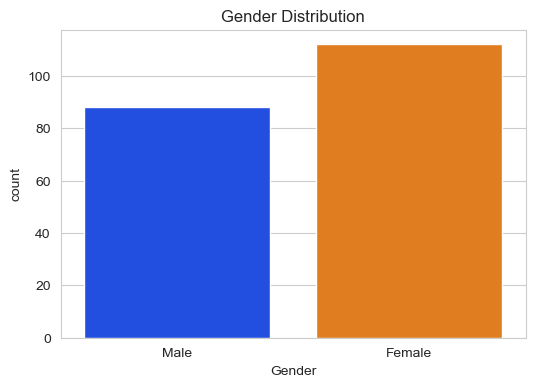

In [4]:
# Visualize Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=mall_df, x="Gender", hue="Gender", palette="bright")
plt.title("Gender Distribution")
plt.show()

### 2.1 Univariate Analysis

To check the relationship between `Gender` with the `Spending Score`

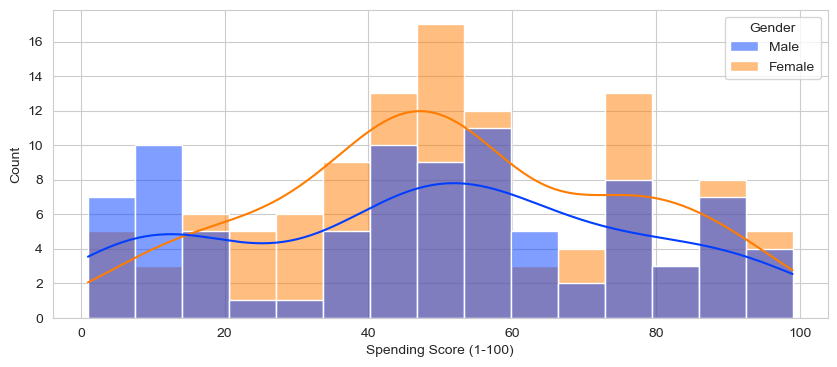

In [5]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=mall_df,
    x="Spending Score (1-100)",
    hue="Gender",
    palette="bright",
    kde=True,
    bins=15,
)
plt.show()

## Step 3: Submission criteria 1 - Gender & Spending Score

We will analyze whether gender plays a significant role in spending habits by comparing summary statistics and visualizing the distribution of 'Spending Score (1-100)' for each gender.

        count       mean       std  min   25%   50%   75%   max
Gender                                                         
Female  112.0  51.526786  24.11495  5.0  35.0  50.0  73.0  99.0
Male     88.0  48.511364  27.89677  1.0  24.5  50.0  70.0  97.0


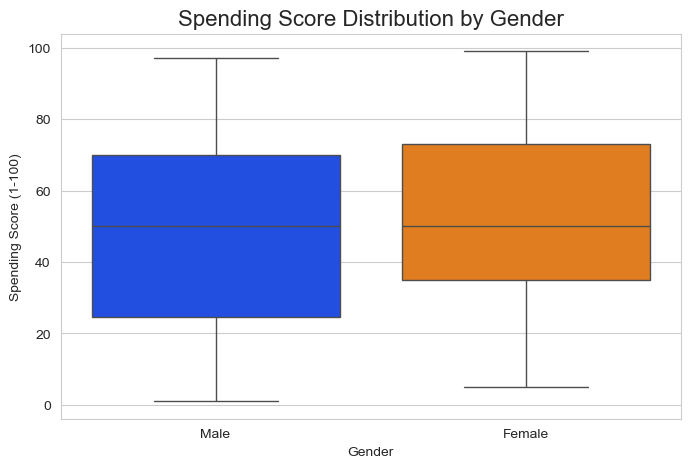

In [6]:
# Summary statistics by gender for Spending Score
gender_stats = mall_df.groupby("Gender")["Spending Score (1-100)"].describe()
print(gender_stats)

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Gender", y="Spending Score (1-100)", hue="Gender", data=mall_df, palette="bright"
)
plt.title("Spending Score Distribution by Gender", fontsize="16")
plt.show()

**The analysis for `Gender` vs. `Spending Score`**
- For Females:
    - Mean Spending Score = ~51.5
    - Standard Deviation = ~24.1
    - Median = 50
- For Males:
    - Mean Spending Score = ~48.5
    - Standard Deviation = ~27.
    - Median = 50
  
**Observation**:
- **Mean Spending**: Female customers have a slightly higher average spending score (51.53) compared to male customers (48.51).
- **Median Spending**: Both genders share the same median spending score (50).
- **Variability**: Male customers exhibit a higher standard deviation (27.90), suggesting a greater spread and more extreme values in their spending scores compared to females (24.11).

## Step 4: Submission criteria 2: Feature engineering for clustering

Clustering is performed using a newly engineered feature combined with the existing Annual Income (k$) to identify distinct customer segments.
`mall_df['Income_to_Spending'] = mall_df['Annual Income (k$)'] / mall_df['Spending Score (1-100)']`

-  Income_to_Spending = $$\frac{Spending Score (1-100)} {Annual Income (k\$)}$$

This ratio captures a customer's efficiency or propensity for saving relative to their income. A high ratio indicates a high income but low spending (more frugal), while a low ratio indicates a low income but high spending (more extravagant).

### 4.1 Creating a new feature

In [7]:
# Feature Engineering -------
# Create a new feature: Income_to_Spending
mall_df["Income_to_Spending"] = (
    mall_df["Annual Income (k$)"] / mall_df["Spending Score (1-100)"]
).round(4)

mall_df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_to_Spending
CustomerID,,,,,
1,Male,19,15,39,0.3846
2,Male,21,15,81,0.1852
3,Female,20,16,6,2.6667
4,Female,23,16,77,0.2078
5,Female,31,17,40,0.4250
...,...,...,...,...,...
196,Female,35,120,79,1.5190
197,Female,45,126,28,4.5000
198,Male,32,126,74,1.7027


### 4.2 Finding the k using elbow method

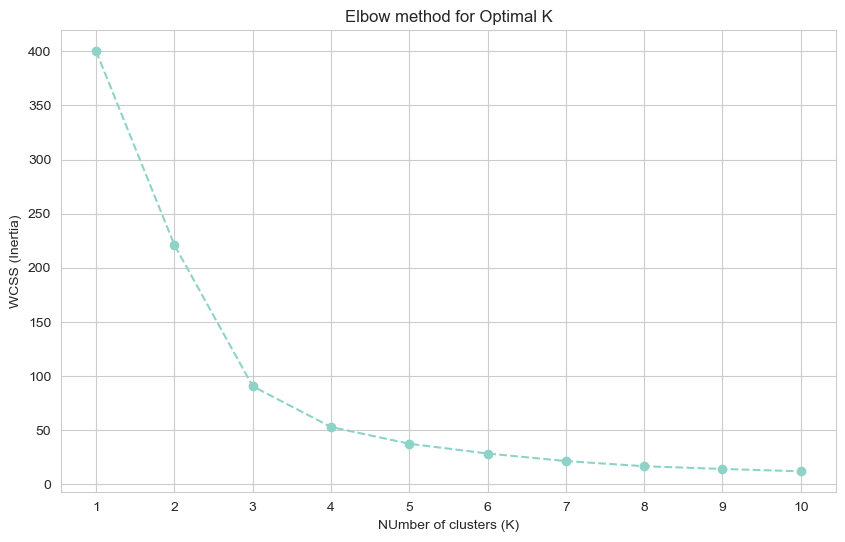

In [8]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.cluster import KMeans

# 1. Select and scale the features
X1 = mall_df[["Income_to_Spending", "Annual Income (k$)"]].values
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

# 2. Implement the elbow method
wcss1 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X1_scaled)
    wcss1.append(kmeans.inertia_)

# 3. Plot the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss1, marker="o", linestyle="--")
plt.title("Elbow method for Optimal K")
plt.xlabel("NUmber of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1, 11))
plt.show()

**Observation**: The 'elbow' of the curve is clearly at **k=5**. The WCSS decreases sharply until k=5, and then the rate of decrease flattens out.

### 4.3 Visualising and Interpreting the segments

In [9]:
# Build and fit the final model
optimal_k = 5
kmeans1 = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init="auto")
mall_df["Income_Cluster"] = kmeans1.fit_predict(X1_scaled)

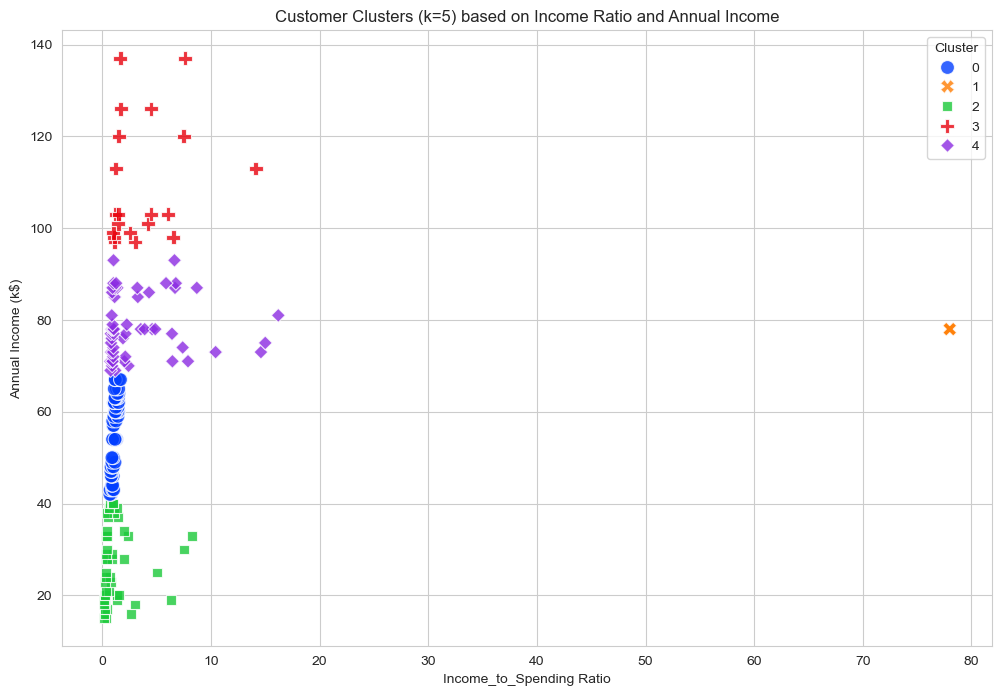

In [10]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=mall_df,
    x="Income_to_Spending",
    y="Annual Income (k$)",
    hue="Income_Cluster",
    palette="bright",
    s=100,
    alpha=0.8,
    style="Income_Cluster",
)
plt.title(f"Customer Clusters (k={optimal_k}) based on Income Ratio and Annual Income")
plt.xlabel("Income_to_Spending Ratio")
plt.ylabel("Annual Income (k$)")
plt.legend(title="Cluster")
plt.show()

In [11]:
# Display the first few rows with the new feature and cluster assignment
print("\nDataFrame with new feature and Cluster assignment:")
mall_df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)",
        "Income_to_Spending",
        "Income_Cluster",
    ]
]


DataFrame with new feature and Cluster assignment:


,Annual Income (k$),Spending Score (1-100),Income_to_Spending,Income_Cluster
CustomerID,,,,
1,15,39,0.3846,2
2,15,81,0.1852,2
3,16,6,2.6667,2
4,16,77,0.2078,2
5,17,40,0.4250,2
...,...,...,...,...
196,120,79,1.5190,3
197,126,28,4.5000,3
198,126,74,1.7027,3


**Obeservation**:

| Cluster | Charaterstics | Segment Name | Strategy |
|-----------|------------------------------------------------------------------------------|--------------------|----------------------------------------------------------------------------------------------------|
| **Cluster 0** | High Income, High Ratio. High income, but low to moderate spending (frugal). | High-Income Savers | Focus on premium, high-margin, investment-type products and loyalty rewards to encourage spending. |
|**Cluster 1** |High Income, Low Ratio. High income with high spending.| High-Value Spenders | Top priority segment. Offer exclusive previews, personalized high-end services, and maintain strong customer relations. |
| Cluster 2 | Low Income, Moderate Ratio. Low to mid income with low to moderate spending (average/budget shoppers). | Budget-Conscious | Focus on promotions, sales, and value-packed bundles. Use targeted ads to increase foot traffic.|
| Cluster 3 | Low Income, Low Ratio. Low income but high spending (extravagant/impulsive). | Low-Income Spenders | Monitor this group. Offer affordable luxury items and installment plans, but with caution to minimize financial risk. | 
| Cluster 4 | Moderate/High Income, Moderate Ratio. Mid-range income and mid-range spending. | Average/Target | Second priority. Offer mid-tier products and try to migrate them to higher-spending clusters with personalized offers.

### 4.4 Using Hierarchical Clustering

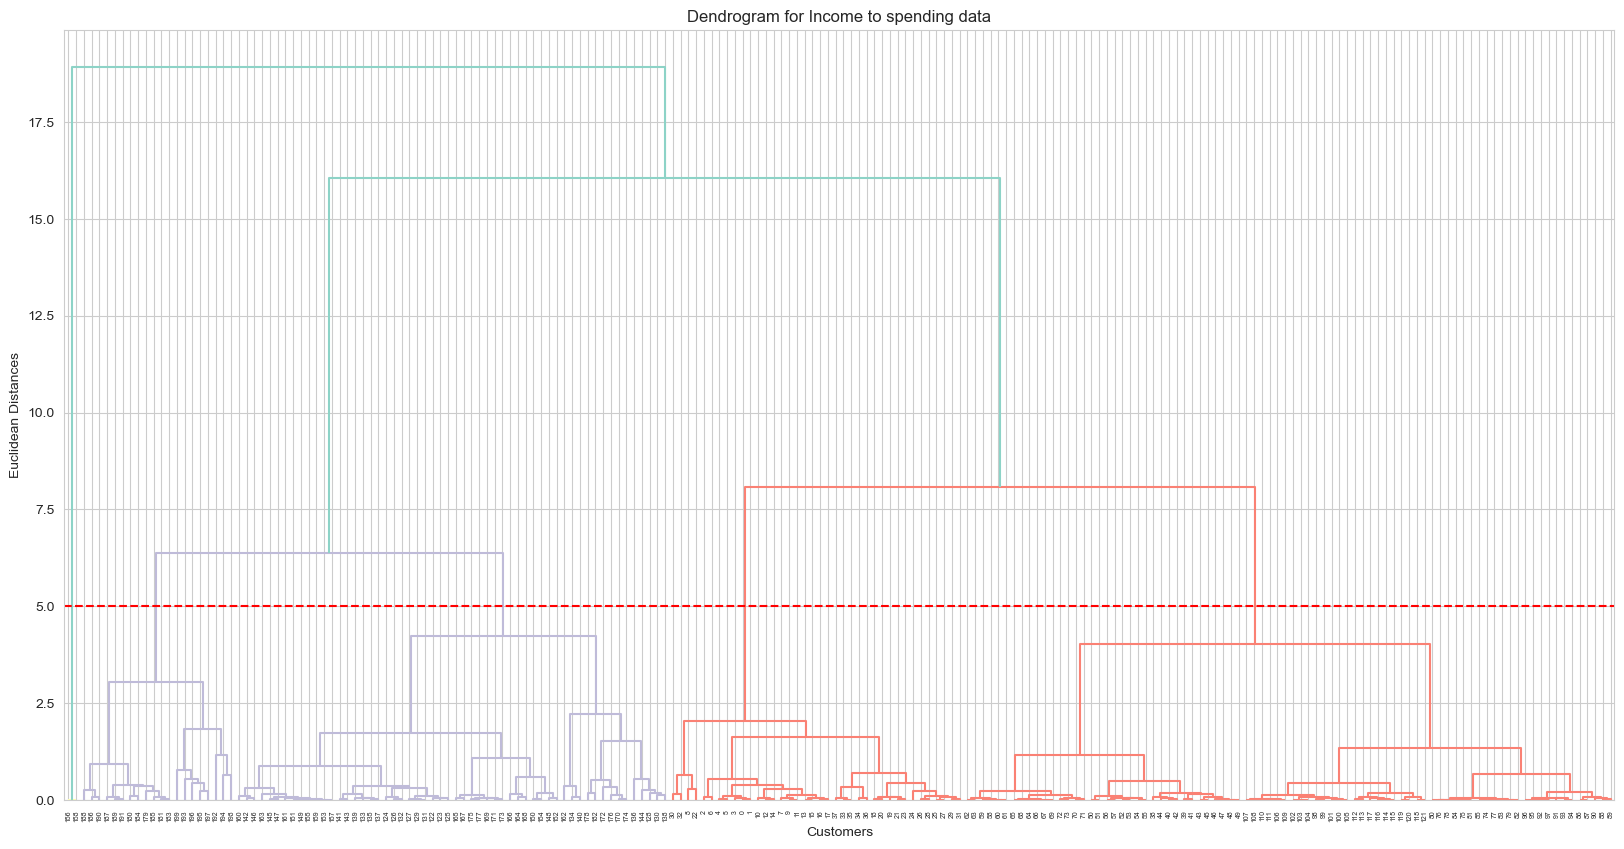

In [12]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(20, 10))
custom_palette = ["red", "blue", "green", "purple", "orange"]

dendrogram = sch.dendrogram(sch.linkage(X1_scaled, method="ward"))
plt.title("Dendrogram for Income to spending data")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distances")
plt.axhline(y=5, color="r", linestyle="--")
plt.show()

**Insight**: The dendrogram also confirms that **5 clusters** is the optimal number for the income-spending data. If we draw a horizontal line at a height of 5 (as shown by the red dashed line), it crossed five vertical line.

## Step 5: Conclusion

In this, i have successfully inplemented the sumbission criteria for the Day 5 project.
### Interpretation & Insights

- **Gender vs. Spending Score:** Summary statistics and boxplots reveal if one gender tends to have higher or lower spending scores.
- **Feature Engineering & Clustering:** The new feature (`Income_to_Spending`) combined with `Annual Income (k$)` enables effective clustering. The Elbow Method helps select the optimal number of clusters, and the scatter plot visualizes distinct customer segments.

These insights can guide targeted marketing and customer engagement strategies.